# Spotify Playlist Explorer

Phase 1 demo: authenticate, pick a playlist (or your
Liked Songs), run six analyzers (genres, tags, release year, top artists,
duration, timeline) with coordinated colorblind palette and
inline coverage annotations, render plots, and optionally export to parquet.
Tag and Genre panels are skipped when `LASTFM_API_KEY` is unset.

> **Note on missing data.** A `PopularityAnalyzer` previously existed but
> was removed: Spotify stopped returning the `popularity` field on tracks and
> artists for apps registered after their 2024-11-27 API deprecation.
> Genre data is sourced from Last.fm via `LastFmClient` (set `LASTFM_API_KEY`
> in `.env` to enable enrichment; without it, genre coverage will be 0%).
> See README → "Spotify Web API limitations" for context.

Setup: load credentials from `.env`, set the seaborn theme, and build a
cached `SpotifyClient`. The cache lives at the repo's `.cache/api/` folder
regardless of where the notebook is launched from (7-day TTL), so repeated
notebook runs don't re-hit the API.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from spotify_project.analyzer import (
    Analyzer,
    ArtistAnalyzer,
    DurationAnalyzer,
    GenreAnalyzer,
    PlaylistAnalyzer,
    TagAnalyzer,
    TimelineAnalyzer,
    YearAnalyzer,
)
from spotify_project.cache import FileCache
from spotify_project.client import SpotifyClient
from spotify_project.lastfm_client import LastFmClient
from spotify_project.logging_setup import configure_logging

load_dotenv()

APP_LOG_LEVEL = os.getenv("APP_LOG_LEVEL", "INFO")
THIRD_PARTY_LOG_LEVEL = os.getenv("THIRD_PARTY_LOG_LEVEL", "WARNING")
configure_logging(APP_LOG_LEVEL, THIRD_PARTY_LOG_LEVEL)

sns.set_theme(style="whitegrid")
cache = FileCache()
lastfm = LastFmClient.from_env(cache=cache)  # None when LASTFM_API_KEY is unset
client = SpotifyClient.from_env(cache=cache, genre_enricher=lastfm)

## 1. Confirm authentication

In [2]:
user = client.fetch_current_user()
truncated_name = user.display_name[0] + "***" if user.display_name else "Unknown"
print(f"Hello, {truncated_name}")

Hello, B***


## 2. List your playlists

Spotify renamed `tracks` → `items` in their Feb 2026 migration. The `items` field is only present on playlists you own or collaborate on; for followed playlists, `tracks` reads as 0.

In [3]:
import pandas as pd

playlists = client.fetch_user_playlists()
summary = pd.DataFrame(
    [
        {
            "id": p.id,
            "name": p.name,
            "tracks": p.track_count,
            "owner": "self" if p.owner_name == user.display_name else "other",
        }
        for p in playlists
    ]
)
summary.head(20)

,id,name,tracks,owner
0,7CmreRETnY6t2MdHrIiaIA,Top 100 Doo Wop Hits 1953-1964,99,other
1,36qmhWCGOAJt6pRScmHcyb,GTA 6 Soundtrack | 2026 GTA VI 🔥🎮,70,other
2,3ebHKSjHujS4Tyt2KKP97R,Retrowave Synthwave,75,other
3,0O3NMz7IEQJCLtO6tXLaq1,Surf Rock Classics,96,other
4,2ZHmECo8IsjfyWDKo0XwfC,Special Groove,37,other
5,5sDWiz1XZevt4T2qOOir50,Liens hochzeit,4,self
6,3v8PWRLiPHGPY0oHgkoZvV,Ben Böhmer [Not Live],20,self
7,5HMBUSi7dMH6N4l0ME6rzE,Chris Tmas,13,self
8,1oMfydMymnL1wQBxiZStDj,Loopthat,1,self
9,0x3U0VtCmPBEImdkpk177b,Rave In Your Grave,142,other


## 3. Pick a playlist and fetch it

Replace `PLAYLIST_ID` below with one of the IDs from the table above.

In [4]:
PLAYLIST_ID = "__liked__"  # or "__liked__" for your saved tracks
playlist = client.fetch_liked_songs() if PLAYLIST_ID == "__liked__" else client.fetch_playlist(PLAYLIST_ID)  # pyright: ignore[reportUnnecessaryComparison]
print(f"{playlist.name}: {len(playlist.tracks)} tracks")

spotify_project.client - INFO - Enriching 3647 tracks with artist data
spotify_project.client - INFO - Fetching 1996 unique artists (~499 s estimate)
Fetching artists: 100%|██████████| 1996/1996 [00:28<00:00, 68.88artist/s]
spotify_project.client - INFO - Enriching 1996 artists with Last.fm tags
Enriching with Last.fm tags: 100%|██████████| 1996/1996 [10:57<00:00,  3.04artist/s]

Liked Songs: 3647 tracks


## 4. Build the PlaylistAnalyzer with all six analyzers

Tweak knobs here:
- `YearAnalyzer(bucket_size=10)` for decade buckets — set to `1` for per-year bars.
- `ArtistAnalyzer(primary_only=True)` to ignore collaborators.
- `TimelineAnalyzer(freq='Y')` for yearly buckets instead of monthly.

Each analyzer reports a small summary DataFrame. Numbers come from the
flattened track DataFrame produced by `PlaylistAnalyzer.from_playlist`.
Coverage attached to each summary surfaces in the chart titles below.

In [5]:
analyzers: list[Analyzer] = [
    GenreAnalyzer(top_n=15),
    TagAnalyzer(top_n=15),
    YearAnalyzer(bucket_size=10),
    ArtistAnalyzer(top_n=15, primary_only=False),
    DurationAnalyzer(bins=20),
    TimelineAnalyzer(freq="M"),
]
analyzer = PlaylistAnalyzer.from_playlist(playlist, analyzers=analyzers)
results = analyzer.run_all()
for title, df in results.items():
    print(title)
    print(df.head(), end="\n\n")

Top Genres
         genre  count
0         rock   1460
1          pop   1349
2   electronic    797
3  alternative    768
4        indie    740

Top Tags
           tag  count
0     american   1574
1         rock   1460
2          pop   1349
3   electronic    797
4  alternative    768

Release Year Distribution
   year  count
0  1940      1
1  1950     65
2  1960    199
3  1970    281
4  1980    261

Top Artists
                artist_id         artist_name  track_count  total_minutes
0  3WrFJ7ztbogyGnTHbHJFl2         The Beatles           60     177.841700
1  4tZwfgrHOc3mvqYlEYSvVi           Daft Punk           55     225.150267
2  75fIuwXxhZ1atNzWLMrgF0         Tyler Bates           43      87.500217
3  1Mxqyy3pSjf8kZZL4QVxS0       Frank Sinatra           43     134.793300
4  1cHFz6lrt7KAsBV8j2Ny1g  The Blues Brothers           39     133.855583

Track Duration Distribution
    bin_low  bin_high  count  minutes_in_bin
0  0.000000  0.621855      9        3.026650
1  0.621855  1.243710 

## 5. Render plots

All six panels stack vertically, each in a distinct colorblind-safe color.
Tag and Genre panels are skipped when `LASTFM_API_KEY` is unset.
`GenreAnalyzer` shows a small grey band at the bottom whenever some
tracks have no genre data — populate `LASTFM_API_KEY` in `.env` to
enable Last.fm enrichment and improve genre coverage.

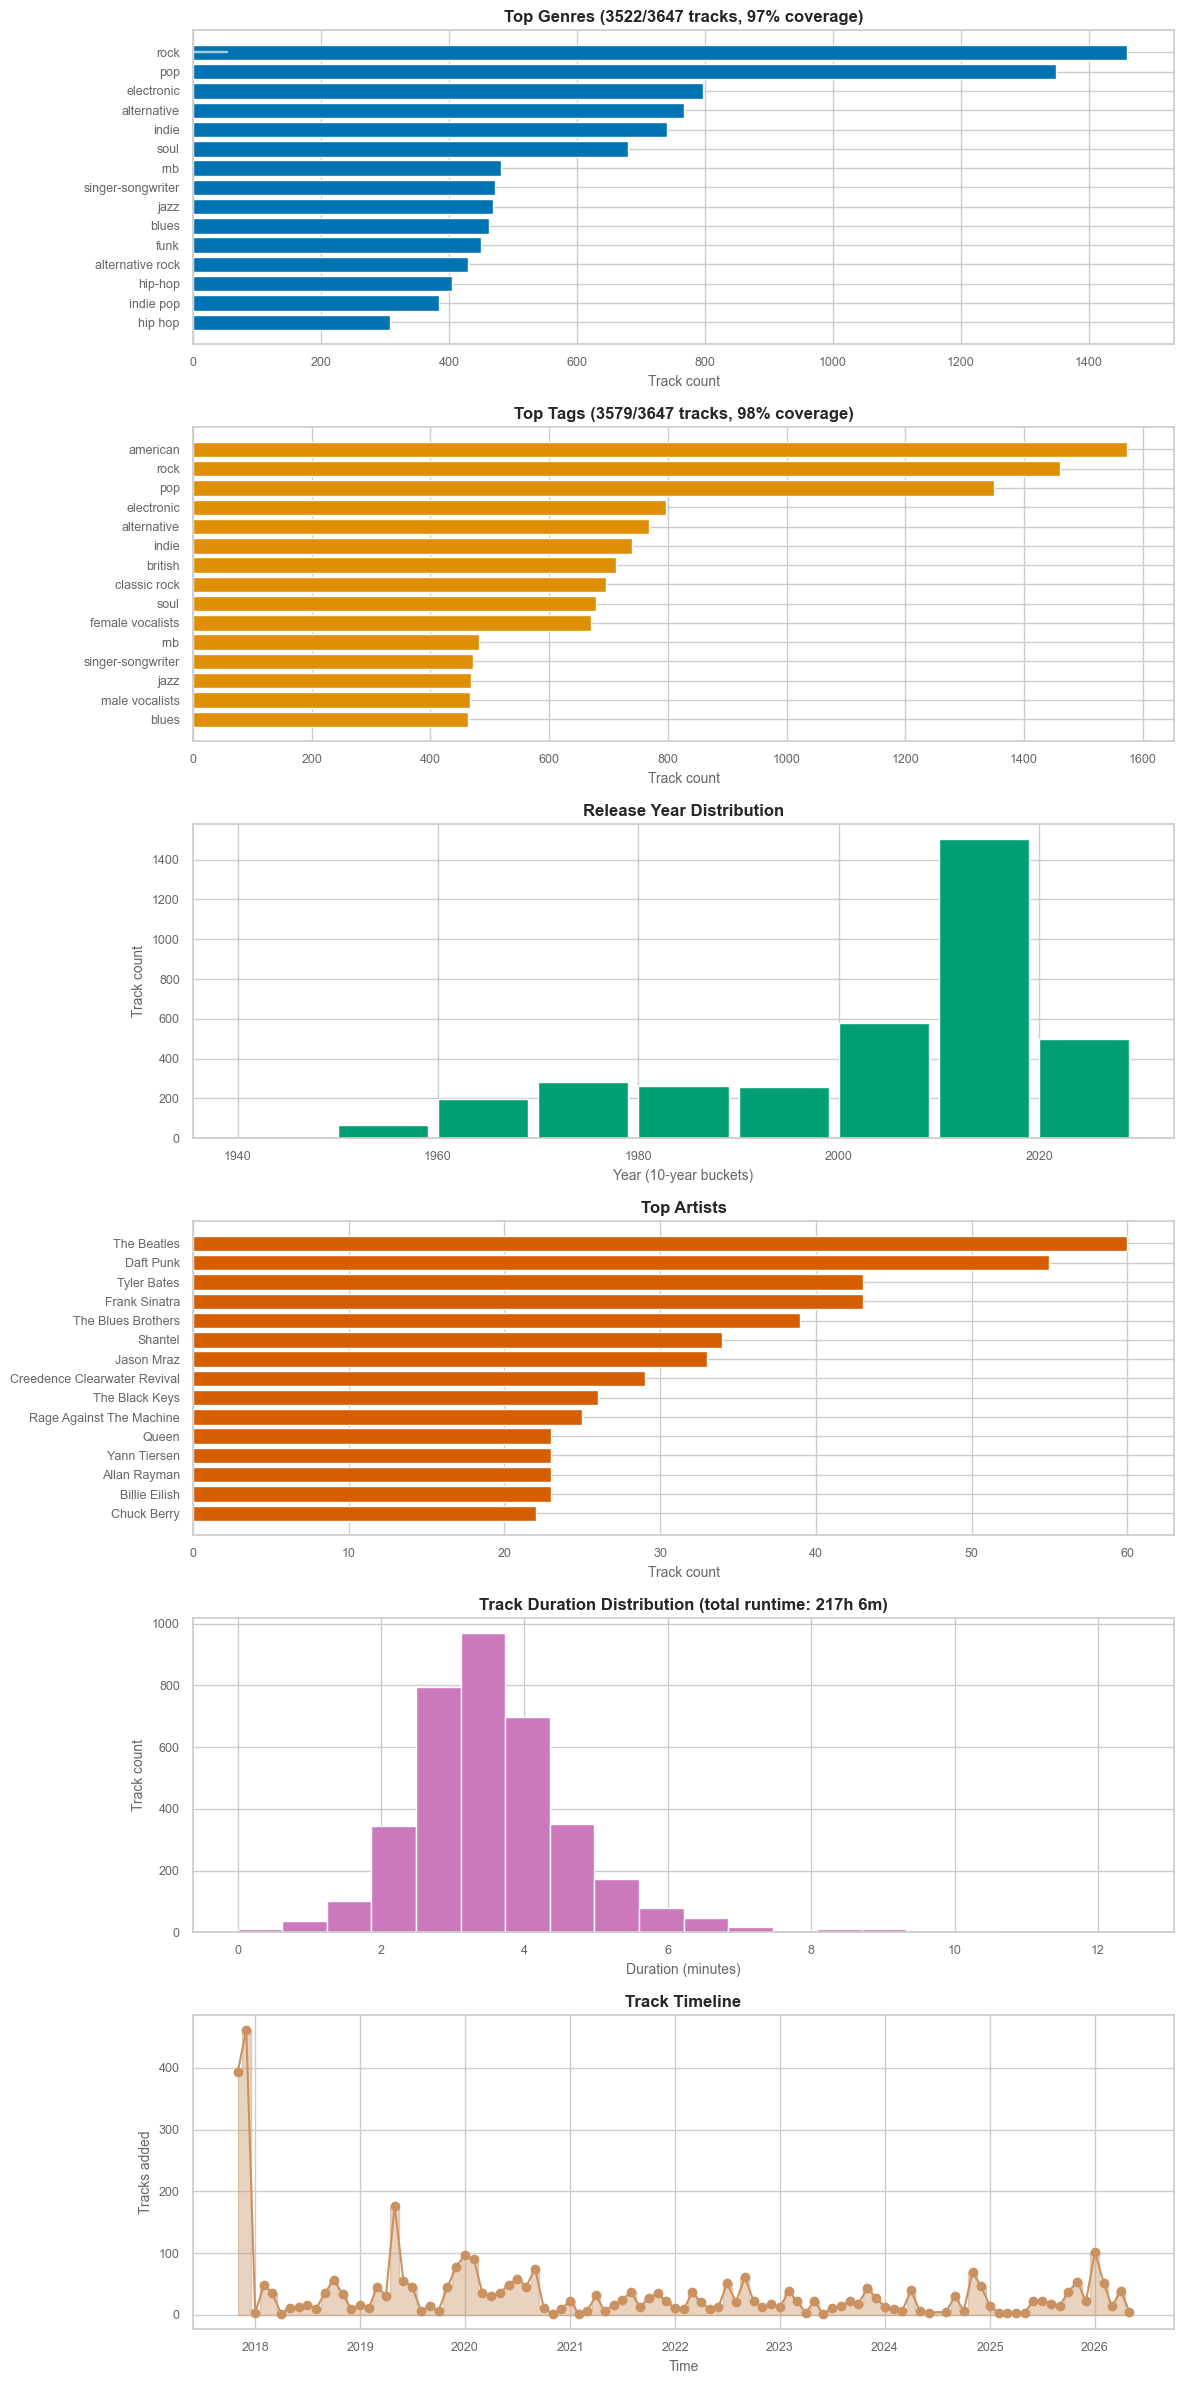

In [6]:
fig = plt.figure(figsize=(12, 24))  # pyright: ignore[reportUnknownMemberType]
analyzer.plot_all(fig)
plt.show()  # pyright: ignore[reportUnknownMemberType]

## 6. (Optional) Export the flattened track DataFrame to parquet

Useful for offline analysis in another tool, or for archiving the snapshot
you analyzed today. The exported parquet preserves the full flattened track
DataFrame (track id/name, primary artist, all artists, album, release date,
duration in minutes, added_at, genres).

In [7]:
EXPORT = False  # set True to write the file
if EXPORT:
    out = Path("exports") / f"{playlist.id}.parquet"
    out.parent.mkdir(parents=True, exist_ok=True)
    analyzer.to_parquet(out)
    print(f"wrote {out}")